In [1]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import functools
print = functools.partial(print, flush=True)

In [2]:
DATA_FILES = [
    (1,  '../ha-1sec-full-rl-v4.pqt'),
    (2,  '../ha-2sec-full-rl-v4.pqt'),
    (3,  '../ha-3sec-full-rl-v4.pqt'),
    (4,  '../ha-4sec-full-rl-v4.pqt'),
    (8,  '../ha-8sec-full-rl-v4.pqt'),
    (16, '../ha-16sec-full-rl-v4.pqt'),
]
OUT_DIR = 'e4_out'
RESUME = True
EPS = 1e-9
W_SCALE = 64
MIN_PER = 8
N_BLOCKS = 10
SLOT_MIN = 30
NMIN = 20
N_PERM = 1000
ROLL = 21
NUM_ROUNDS = 400
PARAMS = {
    'objective': 'regression_l1',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_data_in_leaf': 500,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'force_row_wise': True,
    'verbose': -1,
    'seed': 7,
}

NORM_COLS = ['jmaD1', 'jmaD2', 'haBody', 'haWickTop', 'haWickBott', 'dBody_3']
FEATURES = ['jmaD1', 'haColour', 'jmaD2', 'rsxLast', 'rsxLastD1', 'rsxLastD2',
            'cfbD1', 'haBody', 'candleCross', 'wickAsym', 'haWickTop', 'haWickBott',
            'bodyRange', 'dBody_3', 'dWickTopR_3', 'dWickBotR_3', 'g']
LOAD_COLS = ['timestamp', 'date', 'Open', 'High', 'Low', 'jma', 'jmaD1', 'jmaD2', 'haColour',
             'rsxLast', 'rsxLastD1', 'rsxLastD2', 'cfbD1', 'haBody', 'haWickTop', 'haWickBott']

In [3]:
os.makedirs(OUT_DIR, exist_ok=True)
N_SLOTS = 420 // SLOT_MIN

date_sets = []
for n, path in DATA_FILES:
    date_sets.append(set(pd.read_parquet(path, columns=['date'])['date'].unique()))
shared = np.array(sorted(set.intersection(*date_sets)))
n_days = len(shared)
starts = np.array([b[0] for b in np.array_split(shared, N_BLOCKS)])
N_CELLS = n_days * N_SLOTS
print(f"shared days: {n_days}  slots/day: {N_SLOTS}")

shared days: 1155  slots/day: 14


In [4]:
def prep(df):
    df['haRange'] = df['High'] - df['Low']
    df['candleCross'] = np.sign(df['Open'] - df['jma']).astype('int8')
    df['wickTop_body'] = df['haWickTop'] / (df['haBody'] + EPS)
    df['wickBot_body'] = df['haWickBott'] / (df['haBody'] + EPS)
    df['wickAsym'] = (df['haWickBott'] - df['haWickTop']) / (df['haBody'] + EPS)
    df['bodyRange'] = df['haBody'] / (df['haBody'] + df['haWickTop'] + df['haWickBott'] + EPS)
    gd = df.groupby(df['date'], sort=False)
    df['dBody_3'] = gd['haBody'].diff(3).fillna(0.0).values
    df['dWickTopR_3'] = gd['wickTop_body'].diff(3).fillna(0.0).values
    df['dWickBotR_3'] = gd['wickBot_body'].diff(3).fillna(0.0).values
    scale = gd['haRange'].transform(lambda x: x.rolling(W_SCALE, min_periods=MIN_PER).mean())
    for c in NORM_COLS:
        df[c] = df[c] / scale

def segment(df):
    date = df['date'].to_numpy()
    s = pd.Series(np.sign(df['jmaD1'].to_numpy())).replace(0.0, np.nan)
    s = s.groupby(date).ffill().groupby(date).bfill().to_numpy()
    m = len(df)
    new_day = np.empty(m, dtype=bool); new_day[0] = True
    new_day[1:] = date[1:] != date[:-1]
    flip = np.empty(m, dtype=bool); flip[0] = True
    flip[1:] = s[1:] != s[:-1]
    st = np.flatnonzero(new_day | flip)
    lens = np.diff(np.append(st, m))
    g = np.arange(m) - np.repeat(st, lens) + 1
    df['g'] = g.astype(np.int64)
    df['remaining'] = (np.repeat(lens, lens) - g).astype(np.float32)

In [6]:
# CHATGPT FIXED VERSION

ns = [n for n, _ in DATA_FILES]
K = len(ns)

PARAMS = dict(PARAMS)
PARAMS["num_threads"] = 16

acc = {}

for n, path in DATA_FILES:
    ck = os.path.join(OUT_DIR, f'acc_{n}.npz')

    if RESUME and os.path.exists(ck):
        z = np.load(ck)
        acc[n] = {k: z[k] for k in ('n', 'se', 'sb', 'sa', 'sa2')}
        print(f"n={n}s resumed from checkpoint")
        continue

    df = pd.read_parquet(path, columns=LOAD_COLS)
    df = df[df['date'].isin(shared)].reset_index(drop=True)

    print(f'-- read file: {path}')
    
    prep(df)
    segment(df)

    X = df[FEATURES].to_numpy(np.float32)
    y = df['remaining'].to_numpy(np.float32)
    g = df['g'].to_numpy(np.int64)

    dt = df['date'].to_numpy()
    blk = (np.searchsorted(starts, dt, side='right') - 1).astype(np.int8)

    ts = df['timestamp'].to_numpy()
    md = ((ts - ts.astype('datetime64[D]')) // np.timedelta64(1, 'm')).astype(np.int64)
    slot = np.clip((md - 540) // SLOT_MIN, 0, N_SLOTS - 1)

    cell = np.searchsorted(shared, dt) * N_SLOTS + slot

    del df

    if not np.all(blk[:-1] <= blk[1:]):
        order = np.argsort(blk, kind='stable')
        X = X[order]
        y = y[order]
        g = g[order]
        cell = cell[order]
        blk = blk[order]

    bounds = np.searchsorted(blk, np.arange(N_BLOCKS + 1), side='left')

    a = {k: np.zeros(N_CELLS) for k in ('n', 'se', 'sb', 'sa', 'sa2')}

    print(f'  -- entering blocks loop: {N_BLOCKS}')
    
    for f in range(N_BLOCKS - 1):
        tr_end = bounds[f + 1]
        te0 = bounds[f + 1]
        te1 = bounds[f + 2]

        Xtr = X[:tr_end]
        ytr = y[:tr_end]

        Xte = X[te0:te1]
        yte = y[te0:te1]
        gte = g[te0:te1]
        c = cell[te0:te1]

        dtrain = lgb.Dataset(Xtr, label=ytr)
        mdl = lgb.train(PARAMS, dtrain, num_boost_round=NUM_ROUNDS)

        abs_e = np.abs(mdl.predict(Xte) - yte)

        gt = g[:tr_end]
        gmax = int(gt.max())

        cnt = np.bincount(gt, minlength=gmax + 1)
        sm = np.bincount(gt, weights=ytr, minlength=gmax + 1)

        global_mean = ytr.mean()
        gmean = np.where(cnt > 0, sm / np.maximum(cnt, 1), global_mean)

        pred_b = np.full(len(gte), global_mean, dtype=np.float32)
        known = gte <= gmax
        pred_b[known] = gmean[gte[known]]

        abs_b = np.abs(pred_b - yte)

        adv = abs_b - abs_e

        a['n'] += np.bincount(c, minlength=N_CELLS)
        a['se'] += np.bincount(c, weights=abs_e, minlength=N_CELLS)
        a['sb'] += np.bincount(c, weights=abs_b, minlength=N_CELLS)
        a['sa'] += np.bincount(c, weights=adv, minlength=N_CELLS)
        a['sa2'] += np.bincount(c, weights=adv * adv, minlength=N_CELLS)

        print(f"      n={n}s fold {f} done")

    acc[n] = a
    np.savez(ck, **a)

    del X, y, g, blk, cell

    print('')
    

-- read file: ../ha-1sec-full-rl-v4.pqt
  -- entering blocks loop: 10
n=1s fold 0 done
n=1s fold 1 done
n=1s fold 2 done
n=1s fold 3 done
n=1s fold 4 done
n=1s fold 5 done
n=1s fold 6 done
n=1s fold 7 done
n=1s fold 8 done
-- read file: ../ha-2sec-full-rl-v4.pqt
  -- entering blocks loop: 10
n=2s fold 0 done
n=2s fold 1 done
n=2s fold 2 done
n=2s fold 3 done
n=2s fold 4 done
n=2s fold 5 done
n=2s fold 6 done
n=2s fold 7 done
n=2s fold 8 done
-- read file: ../ha-3sec-full-rl-v4.pqt
  -- entering blocks loop: 10
n=3s fold 0 done
n=3s fold 1 done
n=3s fold 2 done
n=3s fold 3 done
n=3s fold 4 done
n=3s fold 5 done
n=3s fold 6 done
n=3s fold 7 done
n=3s fold 8 done
-- read file: ../ha-4sec-full-rl-v4.pqt
  -- entering blocks loop: 10
n=4s fold 0 done
n=4s fold 1 done
n=4s fold 2 done
n=4s fold 3 done
n=4s fold 4 done
n=4s fold 5 done
n=4s fold 6 done
n=4s fold 7 done
n=4s fold 8 done
-- read file: ../ha-8sec-full-rl-v4.pqt
  -- entering blocks loop: 10
n=8s fold 0 done
n=8s fold 1 done
n=8s

In [7]:
adv_m = np.full((K, N_CELLS), np.nan)
shr_m = np.full((K, N_CELLS), np.nan)
se2_m = np.full((K, N_CELLS), np.nan)
n_m = np.zeros((K, N_CELLS))
skill_day = np.full((K, n_days), np.nan)
long_rows = []
for ki, n in enumerate(ns):
    a = acc[n]
    nn = a['n']
    ok = nn >= NMIN
    adv = np.where(ok, a['sa'] / np.maximum(nn, 1), np.nan)
    var = np.where(ok, a['sa2'] / np.maximum(nn, 1) - adv * adv, np.nan)
    se2 = np.maximum(var / np.maximum(nn, 1), 1e-12)
    mu = a['sa'].sum() / a['n'].sum()
    tau2 = max(float(np.nanvar(adv[ok]) - np.nanmean(se2[ok])), 0.0)
    if tau2 > 0:
        w = 1.0 / se2
        shr = (adv * w + mu / tau2) / (w + 1.0 / tau2)
    else:
        shr = np.where(ok, mu, np.nan)
    adv_m[ki], shr_m[ki], se2_m[ki], n_m[ki] = adv, shr, se2, nn
    se_d = a['se'].reshape(n_days, N_SLOTS).sum(1)
    sb_d = a['sb'].reshape(n_days, N_SLOTS).sum(1)
    skill_day[ki] = np.where(sb_d > 0, 1.0 - se_d / np.maximum(sb_d, 1e-12), np.nan)
    idx = np.flatnonzero(ok)
    long_rows.append(pd.DataFrame({
        'frame': n, 'date': shared[idx // N_SLOTS], 'slot': idx % N_SLOTS,
        'n': nn[idx].astype(np.int64),
        'mae_model': a['se'][idx] / nn[idx], 'mae_bl': a['sb'][idx] / nn[idx],
        'adv': adv[idx], 'se': np.sqrt(se2[idx]), 'shrunk': shr[idx],
        'skill': 1.0 - a['se'][idx] / a['sb'][idx],
    }))
    print(f"n={n}s: tau2={tau2:.5f}  mean_adv={mu:.4f} bars/bar")

pd.concat(long_rows).to_csv(os.path.join(OUT_DIR, 'cells.csv'), index=False)
np.savez(os.path.join(OUT_DIR, 'field.npz'), adv=adv_m, shrunk=shr_m, se2=se2_m,
         n=n_m, frames=np.array(ns), n_slots=N_SLOTS, dates=shared)

common = np.all(n_m >= NMIN, axis=0)
M = adv_m[:, common]
print(f"\ncommon cells (all frames n>={NMIN}): {int(common.sum())} of {N_CELLS}")

n=1s: tau2=0.01539  mean_adv=0.8515 bars/bar
n=2s: tau2=0.02802  mean_adv=0.8707 bars/bar
n=3s: tau2=0.03940  mean_adv=0.8801 bars/bar
n=4s: tau2=0.05115  mean_adv=0.8847 bars/bar
n=8s: tau2=0.09912  mean_adv=0.8888 bars/bar
n=16s: tau2=0.19848  mean_adv=0.8889 bars/bar

common cells (all frames n>=20): 14446 of 16170


In [8]:
def inter_T(P):
    r = P - P.mean(axis=1, keepdims=True) - P.mean(axis=0, keepdims=True) + P.mean()
    return float((r * r).mean())

T_obs = inter_T(M)
rng = np.random.default_rng(1)
ncols = M.shape[1]
Tn = np.empty(N_PERM)

print(f"Permutations: {N_PERM}")

for p_ in range(N_PERM):
    P = np.vstack([np.roll(M[f_], rng.integers(1, ncols)) for f_ in range(K)])
    Tn[p_] = inter_T(P)
pval = (1 + int((Tn >= T_obs).sum())) / (N_PERM + 1)
gm = M.mean()
print(f"frame-main var:  {((M.mean(axis=1) - gm) ** 2).mean():.6g}")
print(f"time-main var:   {((M.mean(axis=0) - gm) ** 2).mean():.6g}")
print(f"interaction+noise (T_obs): {T_obs:.6g}   null mean: {Tn.mean():.6g}   p = {pval:.4g}")
print(f"est. sampling noise (mean se2, common cells): {np.nanmean(se2_m[:, common]):.6g}")

Permutations: 1000
frame-main var:  0.000194009
time-main var:   0.0197282
interaction+noise (T_obs): 0.0783443   null mean: 0.0817284   p = 1
est. sampling noise (mean se2, common cells): 0.0261459



oracle frame-switching adv = 1.1664 bars/bar, best fixed frame = 0.8893, gap = 0.2772  (5.27% of baseline MAE)

skill by slot-of-day:
     09:00  09:30  10:00  10:30  11:00  11:30  12:00  12:30  13:00  13:30  \
1s   15.15  15.32  16.47  15.98  16.64  16.43  16.65  16.40  16.49  16.32   
2s   15.35  15.65  16.40  16.51  16.96  16.50  16.38  16.39  16.59  16.65   
3s   15.57  15.88  16.45  16.88  17.39  16.87  16.56  16.35  16.41  16.61   
4s   15.72  16.34  16.47  17.08  17.39  16.77  16.46  16.37  16.59  16.59   
8s   15.93  16.63  17.18  18.09  16.73  17.54  16.34  15.98  15.92  16.06   
16s  15.92  17.47  17.29  20.28  16.16  19.40  15.42  14.78  14.52  15.03   

     14:00  14:30  15:00  15:30  
1s   16.22  16.56  16.65  16.65  
2s   16.36  17.03  17.07  17.15  
3s   16.51  16.77  17.12  17.69  
4s   16.72  16.69  17.09  17.78  
8s   16.64  16.29  16.35  17.68  
16s  15.94  15.86  16.08  18.23  


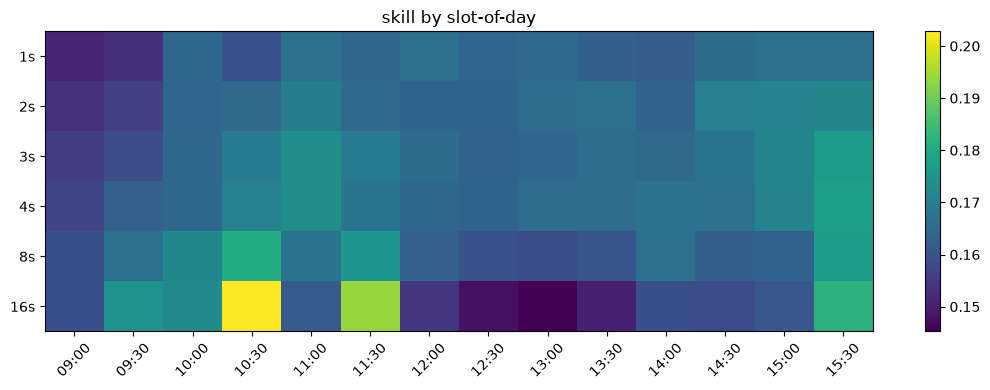

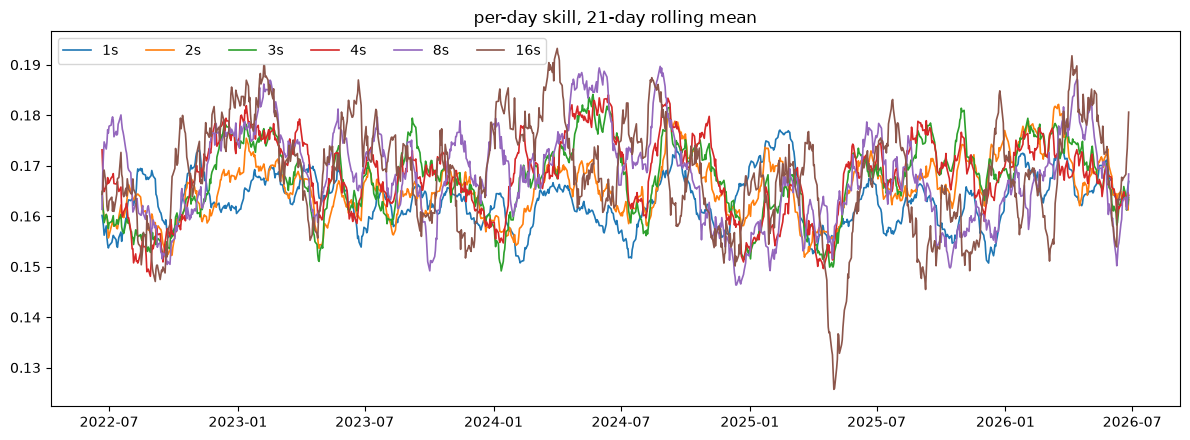

In [9]:
Ms = shr_m[:, common]
oracle = float(Ms.max(axis=0).mean())
fixed = float(Ms.mean(axis=1).max())
bl_bar = sum(acc[n]['sb'].sum() for n in ns) / sum(acc[n]['n'].sum() for n in ns)
print(f"\noracle frame-switching adv = {oracle:.4f} bars/bar, best fixed frame = {fixed:.4f}, "
      f"gap = {oracle - fixed:.4f}  ({(oracle - fixed) / bl_bar * 100:.2f}% of baseline MAE)")

slot_labels = [f"{9 + (k * SLOT_MIN) // 60:02d}:{(k * SLOT_MIN) % 60:02d}" for k in range(N_SLOTS)]
tab = np.zeros((K, N_SLOTS))
for ki, n in enumerate(ns):
    se_s = acc[n]['se'].reshape(n_days, N_SLOTS).sum(0)
    sb_s = acc[n]['sb'].reshape(n_days, N_SLOTS).sum(0)
    tab[ki] = 1.0 - se_s / np.maximum(sb_s, 1e-12)
slot_df = pd.DataFrame(tab, index=[f"{n}s" for n in ns], columns=slot_labels)
print("\nskill by slot-of-day:")
print((slot_df * 100).round(2))
slot_df.to_csv(os.path.join(OUT_DIR, 'slot_frame_skill.csv'))

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(tab, aspect='auto', cmap='viridis')
ax.set_xticks(range(N_SLOTS), slot_labels, rotation=45)
ax.set_yticks(range(K), [f"{n}s" for n in ns])
fig.colorbar(im, ax=ax)
ax.set_title('skill by slot-of-day')
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'slot_frame_skill.png'), dpi=130)

fig, ax = plt.subplots(figsize=(12, 4.5))
for ki, n in enumerate(ns):
    ax.plot(shared, pd.Series(skill_day[ki]).rolling(ROLL, min_periods=5).mean(), lw=1.2, label=f"{n}s")
ax.legend(ncols=6)
ax.set_title(f'per-day skill, {ROLL}-day rolling mean')
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'skill_timeline.png'), dpi=130)
plt.show()